Original Shape: (1460, 81)

Final Shape After Preprocessing: (1460, 223)

Remaining Missing Values:
0

Top 20 Features:
1. OverallQual
2. GrLivArea
3. ExterQual
4. KitchenQual
5. BsmtQual
6. GarageCars
7. GarageArea
8. TotalBsmtSF
9. 1stFlrSF
10. FullBath
11. TotRmsAbvGrd
12. YearBuilt
13. YearRemodAdd
14. Foundation_PConc
15. MasVnrArea
16. Fireplaces
17. GarageYrBlt
18. BsmtFinType1_GLQ
19. HeatingQC
20. Neighborhood_NridgHt

Target Skewness BEFORE Log Transform:
1.8828757597682129

Target Skewness AFTER Log Transform:
0.12134661989685333

X Shape: (1460, 20)
y Shape: (1460,)

Training and Testing Sizes
X_train: (1168, 20)
X_test : (292, 20)
y_train: (1168,)
y_test : (292,)

X_train_scaled Mean:
2.1869872731657193e-16

X_train_scaled Std:
1.0

X_test_scaled Mean:
-0.029132969441064766

X_test_scaled Std:
1.0183421190150275

===== Linear Regression - Training Evaluation =====
MAE: 0.1094
MSE: 0.0252
RMSE: 0.1589
R2: 0.8344
Adjusted_R2: 0.8315
MAPE: 0.9151

===== Linear Regression - Te

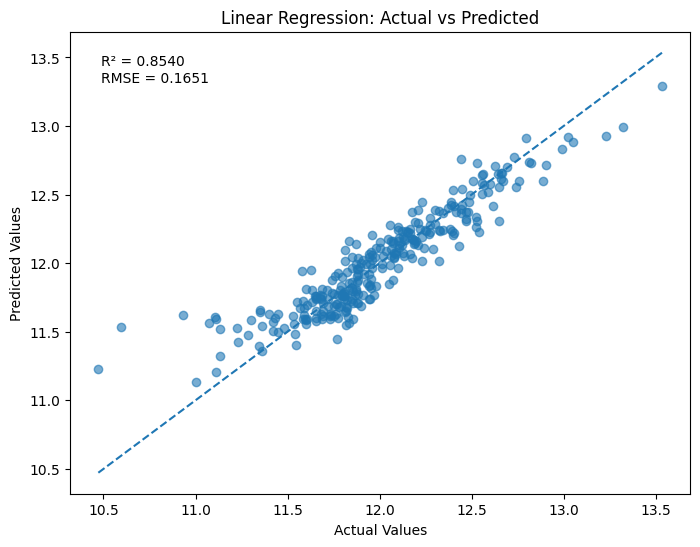

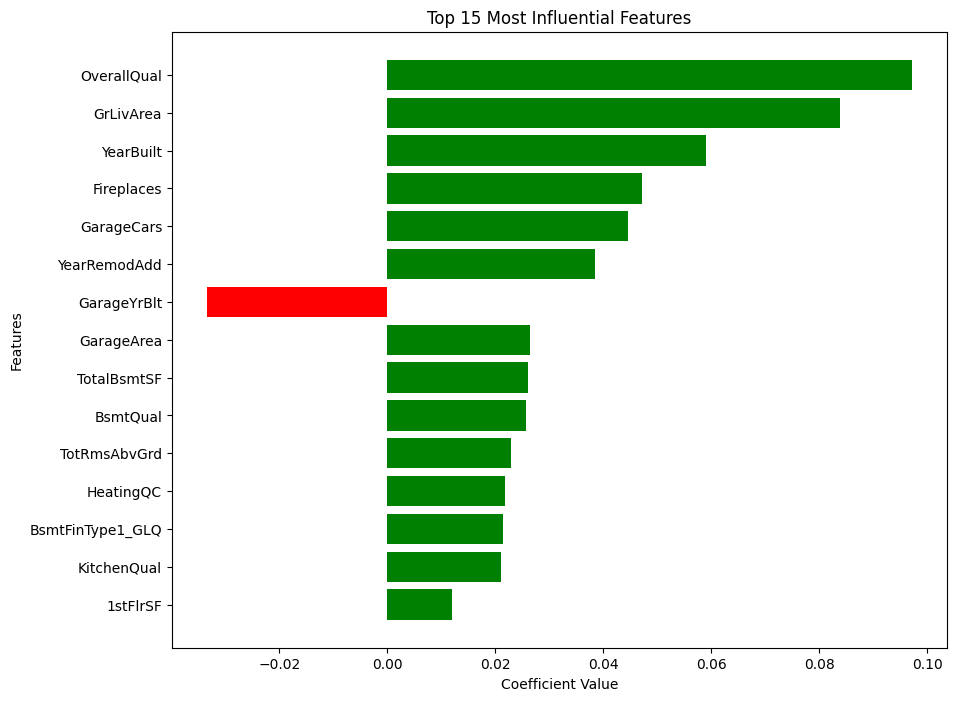


Strongest Positive Feature:
OverallQual
Coefficient: 0.09711398853219527


In [1]:
# ============================================================
# PART A — DATA PREPARATION & BASELINE MODEL (STEPS 1–5)
# House Prices Regression Project
# ============================================================

# ============================================================
# STEP 1 — ENVIRONMENT SETUP & WEEK 3 DATA PIPELINE
# ============================================================

# Import Libraries
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    KFold,
    learning_curve
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("train.csv")

print("Original Shape:", df.shape)

# ------------------------------------------------------------
# Standardize Column Names
# ------------------------------------------------------------
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("/", "_")
)

# ------------------------------------------------------------
# Fill Missing Values
# ------------------------------------------------------------

# Numerical Columns → Median
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical Columns → Mode
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# ------------------------------------------------------------
# Quality Encoding Map
# ------------------------------------------------------------
quality_map = {
    "Ex": 5,
    "Gd": 4,
    "TA": 3,
    "Fa": 2,
    "Po": 1
}

quality_columns = [
    "ExterQual", "ExterCond", "KitchenQual",
    "HeatingQC", "BsmtQual", "BsmtCond",
    "FireplaceQu", "GarageQual", "GarageCond",
    "PoolQC"
]

for col in quality_columns:
    if col in df.columns:
        df[col] = df[col].map(quality_map)

# Fill any remaining NaN after mapping
for col in quality_columns:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# ------------------------------------------------------------
# Frequency Encoding for Neighborhood
# ------------------------------------------------------------
if "Neighborhood" in df.columns:
    freq_encoding = df["Neighborhood"].value_counts().to_dict()
    df["Neighborhood_FE"] = df["Neighborhood"].map(freq_encoding)

# ------------------------------------------------------------
# One-Hot Encoding for Nominal Columns
# ------------------------------------------------------------
df = pd.get_dummies(df, drop_first=True)

# ------------------------------------------------------------
# Final Check
# ------------------------------------------------------------
print("\nFinal Shape After Preprocessing:", df.shape)

print("\nRemaining Missing Values:")
print(df.isnull().sum().sum())


# ============================================================
# STEP 2 — FEATURE SELECTION & TARGET PREPARATION
# ============================================================

# Correlation with SalePrice
correlation = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

# Select Top 20 Features
top_features = correlation.index[1:21].tolist()

# Remove PricePerSF if exists
top_features = [f for f in top_features if f != "PricePerSF"]

print("\nTop 20 Features:")
for i, feature in enumerate(top_features, 1):
    print(f"{i}. {feature}")

# ------------------------------------------------------------
# Target Preparation
# ------------------------------------------------------------

# Original prices
y_original = df["SalePrice"]

# Log Transformation
y = np.log1p(df["SalePrice"])

# Feature Matrix
X = df[top_features]

# ------------------------------------------------------------
# Skewness
# ------------------------------------------------------------
print("\nTarget Skewness BEFORE Log Transform:")
print(y_original.skew())

print("\nTarget Skewness AFTER Log Transform:")
print(y.skew())

# ------------------------------------------------------------
# Shapes
# ------------------------------------------------------------
print("\nX Shape:", X.shape)
print("y Shape:", y.shape)


# ============================================================
# STEP 3 — TRAIN-TEST SPLIT & SCALING
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------------------------
# Print Shapes
# ------------------------------------------------------------
print("\nTraining and Testing Sizes")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# ------------------------------------------------------------
# Standard Scaling
# ------------------------------------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# Verify Scaling
# ------------------------------------------------------------
print("\nX_train_scaled Mean:")
print(np.mean(X_train_scaled))

print("\nX_train_scaled Std:")
print(np.std(X_train_scaled))

print("\nX_test_scaled Mean:")
print(np.mean(X_test_scaled))

print("\nX_test_scaled Std:")
print(np.std(X_test_scaled))


# ============================================================
# STEP 4 — EVALUATION FUNCTIONS
# ============================================================

def evaluate_model(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    model_name: str,
    n_features: int
) -> dict:
    """
    Evaluate regression model performance.

    Parameters
    ----------
    y_true : np.ndarray
        Actual target values.

    y_pred : np.ndarray
        Predicted target values.

    model_name : str
        Name of the regression model.

    n_features : int
        Number of features used in the model.

    Returns
    -------
    dict
        Dictionary containing evaluation metrics.
    """

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    n = len(y_true)

    adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - n_features - 1))

    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    results = {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted_R2": adjusted_r2,
        "MAPE": mape
    }

    print(f"\n===== {model_name} Evaluation =====")
    for key, value in results.items():
        if key != "Model":
            print(f"{key}: {value:.4f}")

    return results


def plot_actual_vs_predicted(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    model_name: str
) -> None:
    """
    Plot Actual vs Predicted values.

    Parameters
    ----------
    y_true : np.ndarray
        Actual values.

    y_pred : np.ndarray
        Predicted values.

    model_name : str
        Name of model.
    """

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    plt.figure(figsize=(8, 6))

    plt.scatter(y_true, y_pred, alpha=0.6)

    # Perfect Prediction Line
    plt.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        linestyle="--"
    )

    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{model_name}: Actual vs Predicted")

    plt.text(
        0.05,
        0.95,
        f"R² = {r2:.4f}\nRMSE = {rmse:.4f}",
        transform=plt.gca().transAxes,
        verticalalignment="top"
    )

    plt.show()


# ============================================================
# STEP 5 — BASELINE MODEL: LINEAR REGRESSION
# ============================================================

# Train Model
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------
train_results = evaluate_model(
    y_train,
    y_train_pred,
    "Linear Regression - Training",
    X_train.shape[1]
)

test_results = evaluate_model(
    y_test,
    y_test_pred,
    "Linear Regression - Testing",
    X_test.shape[1]
)

# ------------------------------------------------------------
# Plot Actual vs Predicted
# ------------------------------------------------------------
plot_actual_vs_predicted(
    y_test,
    y_test_pred,
    "Linear Regression"
)

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coefficients["Abs_Coefficient"] = coefficients["Coefficient"].abs()

top_coefficients = coefficients.sort_values(
    by="Abs_Coefficient",
    ascending=False
).head(15)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 8))

colors = [
    "green" if val > 0 else "red"
    for val in top_coefficients["Coefficient"]
]

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"],
    color=colors
)

plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.title("Top 15 Most Influential Features")

plt.gca().invert_yaxis()

plt.show()

# ------------------------------------------------------------
# Strongest Positive Feature
# ------------------------------------------------------------
strongest_positive = coefficients.sort_values(
    by="Coefficient",
    ascending=False
).iloc[0]

print("\nStrongest Positive Feature:")
print(strongest_positive["Feature"])
print("Coefficient:", strongest_positive["Coefficient"])


Polynomial Regression Comparison
   Degree  n_features_after_expansion  train_R2      test_R2          gap
0       1                          20  0.834384     0.854011    -0.019627
1       2                         230  0.905719     0.838763     0.066956
2       3                        1770  0.999919 -3983.049039  3984.048958


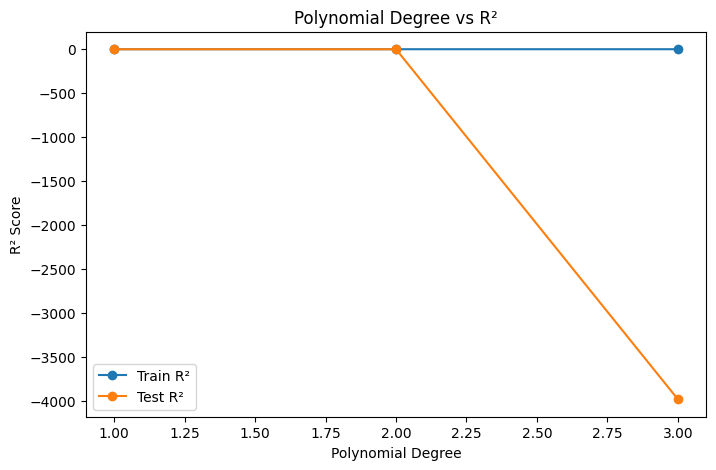


Ridge Results
      alpha      RMSE        R2
0     0.001  0.165055  0.854011
1     0.010  0.165055  0.854011
2     0.100  0.165055  0.854010
3     1.000  0.165060  0.854002
4    10.000  0.165117  0.853901
5   100.000  0.166143  0.852080
6   500.000  0.172152  0.841186
7  1000.000  0.179686  0.826982


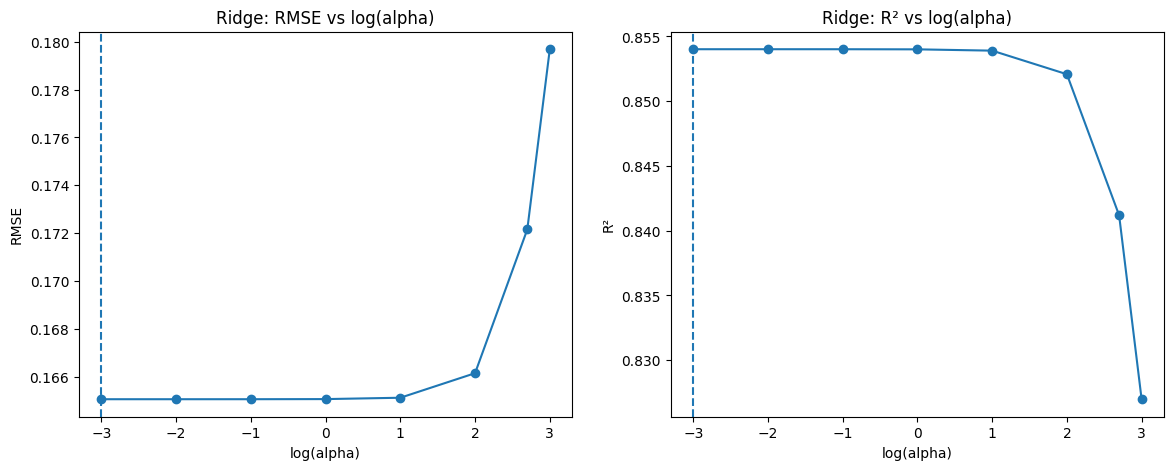


Best Ridge Alpha (GridSearchCV):
{'alpha': 100}

===== Best Ridge Evaluation =====
MAE: 0.1191
MSE: 0.0276
RMSE: 0.1661
R2: 0.8521
Adjusted_R2: 0.8412
MAPE: 1.0050

Lasso Results
     alpha  n_features_eliminated  pct_eliminated  test_RMSE   test_R2
0   0.0001                      0             0.0   0.165035  0.854047
1   0.0010                      1             5.0   0.164994  0.854119
2   0.0100                      6            30.0   0.168373  0.848082
3   0.1000                     14            70.0   0.239359  0.692983
4   1.0000                     20           100.0   0.433244 -0.005837
5  10.0000                     20           100.0   0.433244 -0.005837


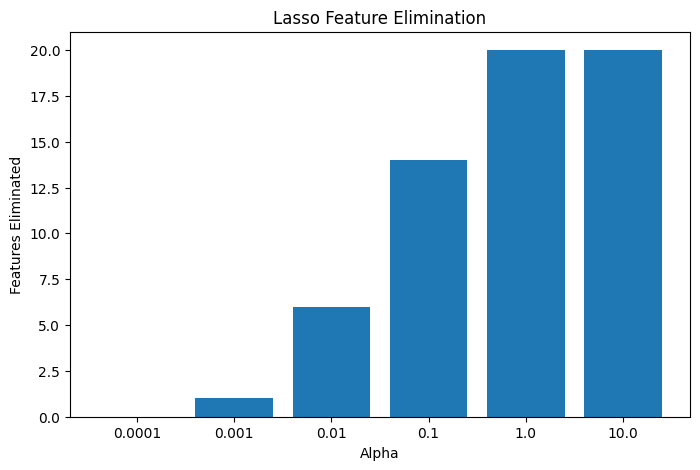


Best Lasso Alpha:
{'alpha': 0.001}

===== Best Lasso Evaluation =====
MAE: 0.1186
MSE: 0.0272
RMSE: 0.1650
R2: 0.8541
Adjusted_R2: 0.8434
MAPE: 1.0007

Features Survived:
['OverallQual', 'GrLivArea', 'KitchenQual', 'BsmtQual', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd', 'Foundation_PConc', 'MasVnrArea', 'Fireplaces', 'GarageYrBlt', 'BsmtFinType1_GLQ', 'HeatingQC', 'Neighborhood_NridgHt']

Features Eliminated:
['ExterQual']


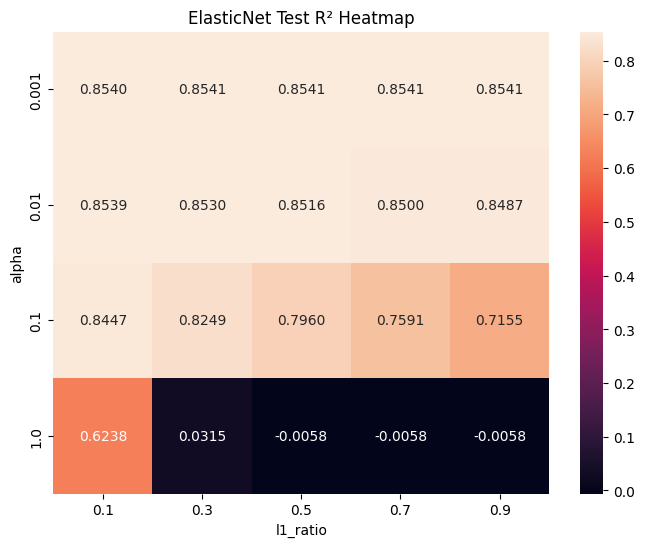


Best ElasticNet Parameters:
{'alpha': 0.01, 'l1_ratio': 0.3}

===== Best ElasticNet Evaluation =====
MAE: 0.1193
MSE: 0.0274
RMSE: 0.1656
R2: 0.8530
Adjusted_R2: 0.8422
MAPE: 1.0064

Best Pipeline Parameters:
{'poly__degree': 2, 'ridge__alpha': 10}

===== Polynomial + Ridge Pipeline Evaluation =====
MAE: 0.1133
MSE: 0.0260
RMSE: 0.1613
R2: 0.8606
Adjusted_R2: 0.8503
MAPE: 0.9547


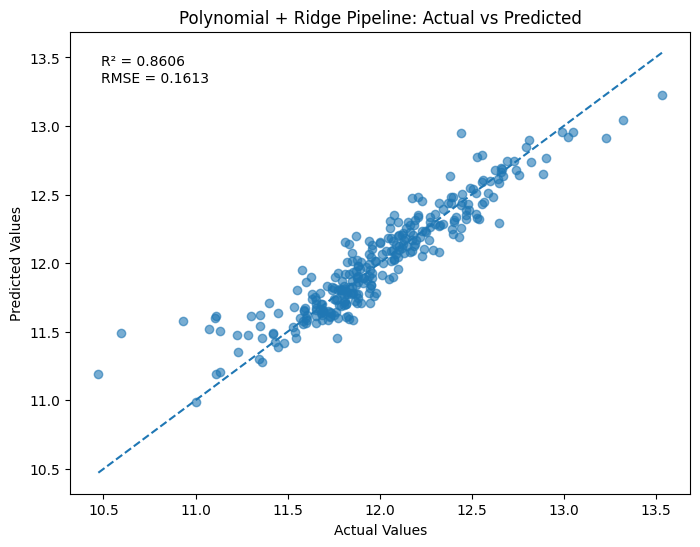


===== Linear Regression Evaluation =====
MAE: 0.1186
MSE: 0.0272
RMSE: 0.1651
R2: 0.8540
Adjusted_R2: 0.8432
MAPE: 1.0000

Final Model Comparison
                         Model       MAE       MSE      RMSE        R2  \
0            Linear Regression  0.118571  0.027243  0.165055  0.854011   
1                   Best Ridge  0.119126  0.027604  0.166143  0.852080   
2                   Best Lasso  0.118642  0.027223  0.164994  0.854119   
3              Best ElasticNet  0.119323  0.027427  0.165612  0.853024   
4  Polynomial + Ridge Pipeline  0.113330  0.026008  0.161270  0.860629   

   Adjusted_R2      MAPE  Dollar_RMSE  
0     0.843237  0.999980     0.179458  
1     0.841163  1.005049     0.180742  
2     0.843352  1.000728     0.179386  
3     0.842178  1.006428     0.180115  
4     0.850344  0.954714     0.175003  


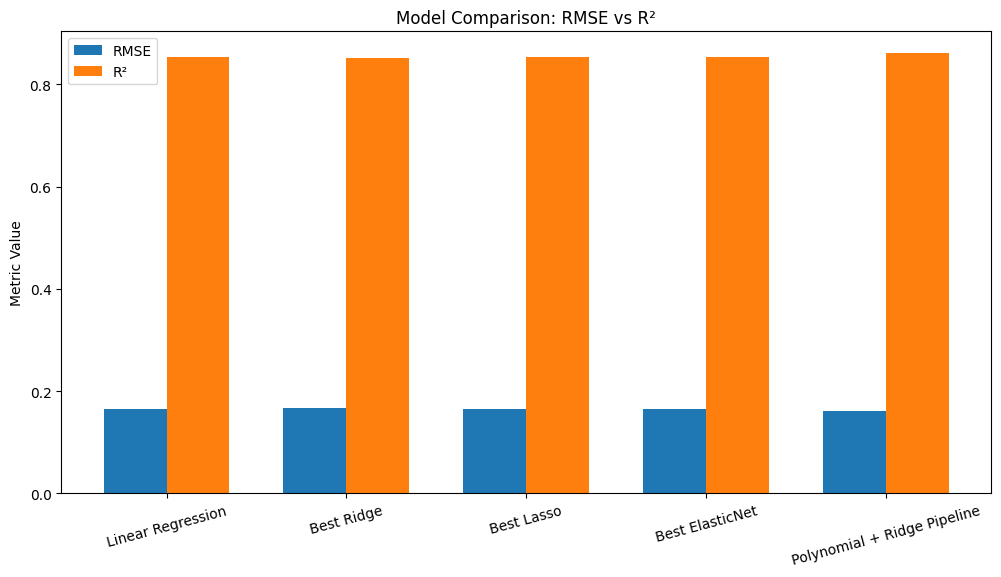


Best Model:
Polynomial + Ridge Pipeline

Worst Model:
Best Ridge


In [2]:
# ============================================================
# PART B — POLYNOMIAL & REGULARIZED MODELS (STEPS 6–11)
# ============================================================

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# STEP 6 — POLYNOMIAL REGRESSION (DEGREE COMPARISON)
# ============================================================

poly_results = []

degrees = [1, 2, 3]

for degree in degrees:

    # Polynomial Features
    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Scaling
    scaler_poly = StandardScaler()

    X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
    X_test_poly_scaled = scaler_poly.transform(X_test_poly)

    # Linear Regression
    model = LinearRegression()

    model.fit(X_train_poly_scaled, y_train)

    # Predictions
    train_pred = model.predict(X_train_poly_scaled)
    test_pred = model.predict(X_test_poly_scaled)

    # Scores
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    gap = train_r2 - test_r2

    poly_results.append({
        "Degree": degree,
        "n_features_after_expansion": X_train_poly.shape[1],
        "train_R2": train_r2,
        "test_R2": test_r2,
        "gap": gap
    })

# ------------------------------------------------------------
# Results Table
# ------------------------------------------------------------
poly_results_df = pd.DataFrame(poly_results)

print("\nPolynomial Regression Comparison")
print(poly_results_df)

# ------------------------------------------------------------
# Plot Train/Test R²
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    poly_results_df["Degree"],
    poly_results_df["train_R2"],
    marker="o",
    label="Train R²"
)

plt.plot(
    poly_results_df["Degree"],
    poly_results_df["test_R2"],
    marker="o",
    label="Test R²"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")
plt.title("Polynomial Degree vs R²")
plt.legend()

plt.show()


# ============================================================
# STEP 7 — RIDGE REGRESSION (ALPHA EXPLORATION)
# ============================================================

ridge_alphas = [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]

ridge_results = []

for alpha in ridge_alphas:

    ridge_model = Ridge(alpha=alpha)

    ridge_model.fit(X_train_scaled, y_train)

    ridge_pred = ridge_model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
    r2 = r2_score(y_test, ridge_pred)

    ridge_results.append({
        "alpha": alpha,
        "RMSE": rmse,
        "R2": r2
    })

ridge_results_df = pd.DataFrame(ridge_results)

print("\nRidge Results")
print(ridge_results_df)

# ------------------------------------------------------------
# Best Manual Alpha
# ------------------------------------------------------------
best_manual_alpha = ridge_results_df.sort_values(
    by="R2",
    ascending=False
).iloc[0]["alpha"]

# ------------------------------------------------------------
# Plots
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE Plot
axes[0].plot(
    np.log10(ridge_results_df["alpha"]),
    ridge_results_df["RMSE"],
    marker="o"
)

axes[0].axvline(
    np.log10(best_manual_alpha),
    linestyle="--"
)

axes[0].set_xlabel("log(alpha)")
axes[0].set_ylabel("RMSE")
axes[0].set_title("Ridge: RMSE vs log(alpha)")

# R² Plot
axes[1].plot(
    np.log10(ridge_results_df["alpha"]),
    ridge_results_df["R2"],
    marker="o"
)

axes[1].axvline(
    np.log10(best_manual_alpha),
    linestyle="--"
)

axes[1].set_xlabel("log(alpha)")
axes[1].set_ylabel("R²")
axes[1].set_title("Ridge: R² vs log(alpha)")

plt.show()

# ------------------------------------------------------------
# GridSearchCV for Ridge
# ------------------------------------------------------------
ridge_param_grid = {
    "alpha": ridge_alphas
}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_param_grid,
    cv=5,
    scoring="r2"
)

ridge_grid.fit(X_train_scaled, y_train)

best_ridge_model = ridge_grid.best_estimator_

print("\nBest Ridge Alpha (GridSearchCV):")
print(ridge_grid.best_params_)

ridge_best_pred = best_ridge_model.predict(X_test_scaled)

ridge_best_results = evaluate_model(
    y_test,
    ridge_best_pred,
    "Best Ridge",
    X_test.shape[1]
)


# ============================================================
# STEP 8 — LASSO REGRESSION (FEATURE ELIMINATION)
# ============================================================

lasso_alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10]

lasso_results = []

for alpha in lasso_alphas:

    lasso_model = Lasso(alpha=alpha, max_iter=10000)

    lasso_model.fit(X_train_scaled, y_train)

    lasso_pred = lasso_model.predict(X_test_scaled)

    zero_count = np.sum(lasso_model.coef_ == 0)

    pct_eliminated = (zero_count / len(lasso_model.coef_)) * 100

    rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
    r2 = r2_score(y_test, lasso_pred)

    lasso_results.append({
        "alpha": alpha,
        "n_features_eliminated": zero_count,
        "pct_eliminated": pct_eliminated,
        "test_RMSE": rmse,
        "test_R2": r2
    })

lasso_results_df = pd.DataFrame(lasso_results)

print("\nLasso Results")
print(lasso_results_df)

# ------------------------------------------------------------
# Bar Chart
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.bar(
    lasso_results_df["alpha"].astype(str),
    lasso_results_df["n_features_eliminated"]
)

plt.xlabel("Alpha")
plt.ylabel("Features Eliminated")
plt.title("Lasso Feature Elimination")

plt.show()

# ------------------------------------------------------------
# GridSearchCV
# ------------------------------------------------------------
lasso_param_grid = {
    "alpha": lasso_alphas
}

lasso_grid = GridSearchCV(
    Lasso(max_iter=10000),
    lasso_param_grid,
    cv=5,
    scoring="r2"
)

lasso_grid.fit(X_train_scaled, y_train)

best_lasso_model = lasso_grid.best_estimator_

print("\nBest Lasso Alpha:")
print(lasso_grid.best_params_)

lasso_best_pred = best_lasso_model.predict(X_test_scaled)

lasso_best_results = evaluate_model(
    y_test,
    lasso_best_pred,
    "Best Lasso",
    X_test.shape[1]
)

# ------------------------------------------------------------
# Features Survived vs Eliminated
# ------------------------------------------------------------
lasso_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_lasso_model.coef_
})

survived_features = lasso_coefficients[
    lasso_coefficients["Coefficient"] != 0
]["Feature"].tolist()

eliminated_features = lasso_coefficients[
    lasso_coefficients["Coefficient"] == 0
]["Feature"].tolist()

print("\nFeatures Survived:")
print(survived_features)

print("\nFeatures Eliminated:")
print(eliminated_features)


# ============================================================
# STEP 9 — ELASTICNET
# ============================================================

elastic_alphas = [0.001, 0.01, 0.1, 1]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

heatmap_results = pd.DataFrame(
    index=elastic_alphas,
    columns=l1_ratios
)

for alpha in elastic_alphas:

    for ratio in l1_ratios:

        elastic_model = ElasticNet(
            alpha=alpha,
            l1_ratio=ratio,
            max_iter=10000
        )

        elastic_model.fit(X_train_scaled, y_train)

        pred = elastic_model.predict(X_test_scaled)

        r2 = r2_score(y_test, pred)

        heatmap_results.loc[alpha, ratio] = r2

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

sns.heatmap(
    heatmap_results.astype(float),
    annot=True,
    fmt=".4f"
)

plt.title("ElasticNet Test R² Heatmap")

plt.xlabel("l1_ratio")
plt.ylabel("alpha")

plt.show()

# ------------------------------------------------------------
# GridSearchCV
# ------------------------------------------------------------
elastic_param_grid = {
    "alpha": elastic_alphas,
    "l1_ratio": l1_ratios
}

elastic_grid = GridSearchCV(
    ElasticNet(max_iter=10000),
    elastic_param_grid,
    cv=5,
    scoring="r2"
)

elastic_grid.fit(X_train_scaled, y_train)

best_elastic_model = elastic_grid.best_estimator_

print("\nBest ElasticNet Parameters:")
print(elastic_grid.best_params_)

elastic_pred = best_elastic_model.predict(X_test_scaled)

elastic_results = evaluate_model(
    y_test,
    elastic_pred,
    "Best ElasticNet",
    X_test.shape[1]
)


# ============================================================
# STEP 10 — POLYNOMIAL + RIDGE PIPELINE
# ============================================================

pipeline = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

pipeline_param_grid = {
    "poly__degree": [1, 2],
    "ridge__alpha": [0.01, 0.1, 1, 10, 100]
}

pipeline_grid = GridSearchCV(
    pipeline,
    pipeline_param_grid,
    cv=5,
    scoring="r2"
)

pipeline_grid.fit(X_train, y_train)

best_pipeline_model = pipeline_grid.best_estimator_

print("\nBest Pipeline Parameters:")
print(pipeline_grid.best_params_)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------
pipeline_pred = best_pipeline_model.predict(X_test)

pipeline_results = evaluate_model(
    y_test,
    pipeline_pred,
    "Polynomial + Ridge Pipeline",
    X_test.shape[1]
)

# ------------------------------------------------------------
# Actual vs Predicted Plot
# ------------------------------------------------------------
plot_actual_vs_predicted(
    y_test,
    pipeline_pred,
    "Polynomial + Ridge Pipeline"
)


# ============================================================
# STEP 11 — FINAL MODEL COMPARISON
# ============================================================

# ------------------------------------------------------------
# Linear Regression Results
# ------------------------------------------------------------
linear_results = evaluate_model(
    y_test,
    y_test_pred,
    "Linear Regression",
    X_test.shape[1]
)

# ------------------------------------------------------------
# Collect Results
# ------------------------------------------------------------
all_results = pd.DataFrame([
    linear_results,
    ridge_best_results,
    lasso_best_results,
    elastic_results,
    pipeline_results
])

# ------------------------------------------------------------
# Dollar RMSE
# ------------------------------------------------------------
all_results["Dollar_RMSE"] = np.expm1(all_results["RMSE"])

# ------------------------------------------------------------
# Final Comparison Table
# ------------------------------------------------------------
print("\nFinal Model Comparison")
print(all_results)

# ------------------------------------------------------------
# Grouped Bar Chart
# ------------------------------------------------------------
x = np.arange(len(all_results["Model"]))

width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width/2,
    all_results["RMSE"],
    width,
    label="RMSE"
)

plt.bar(
    x + width/2,
    all_results["R2"],
    width,
    label="R²"
)

plt.xticks(
    x,
    all_results["Model"],
    rotation=15
)

plt.ylabel("Metric Value")
plt.title("Model Comparison: RMSE vs R²")
plt.legend()

plt.show()

# ------------------------------------------------------------
# Best and Worst Models
# ------------------------------------------------------------
best_model = all_results.sort_values(
    by="R2",
    ascending=False
).iloc[0]

worst_model = all_results.sort_values(
    by="R2",
    ascending=True
).iloc[0]

print("\nBest Model:")
print(best_model["Model"])

print("\nWorst Model:")
print(worst_model["Model"])

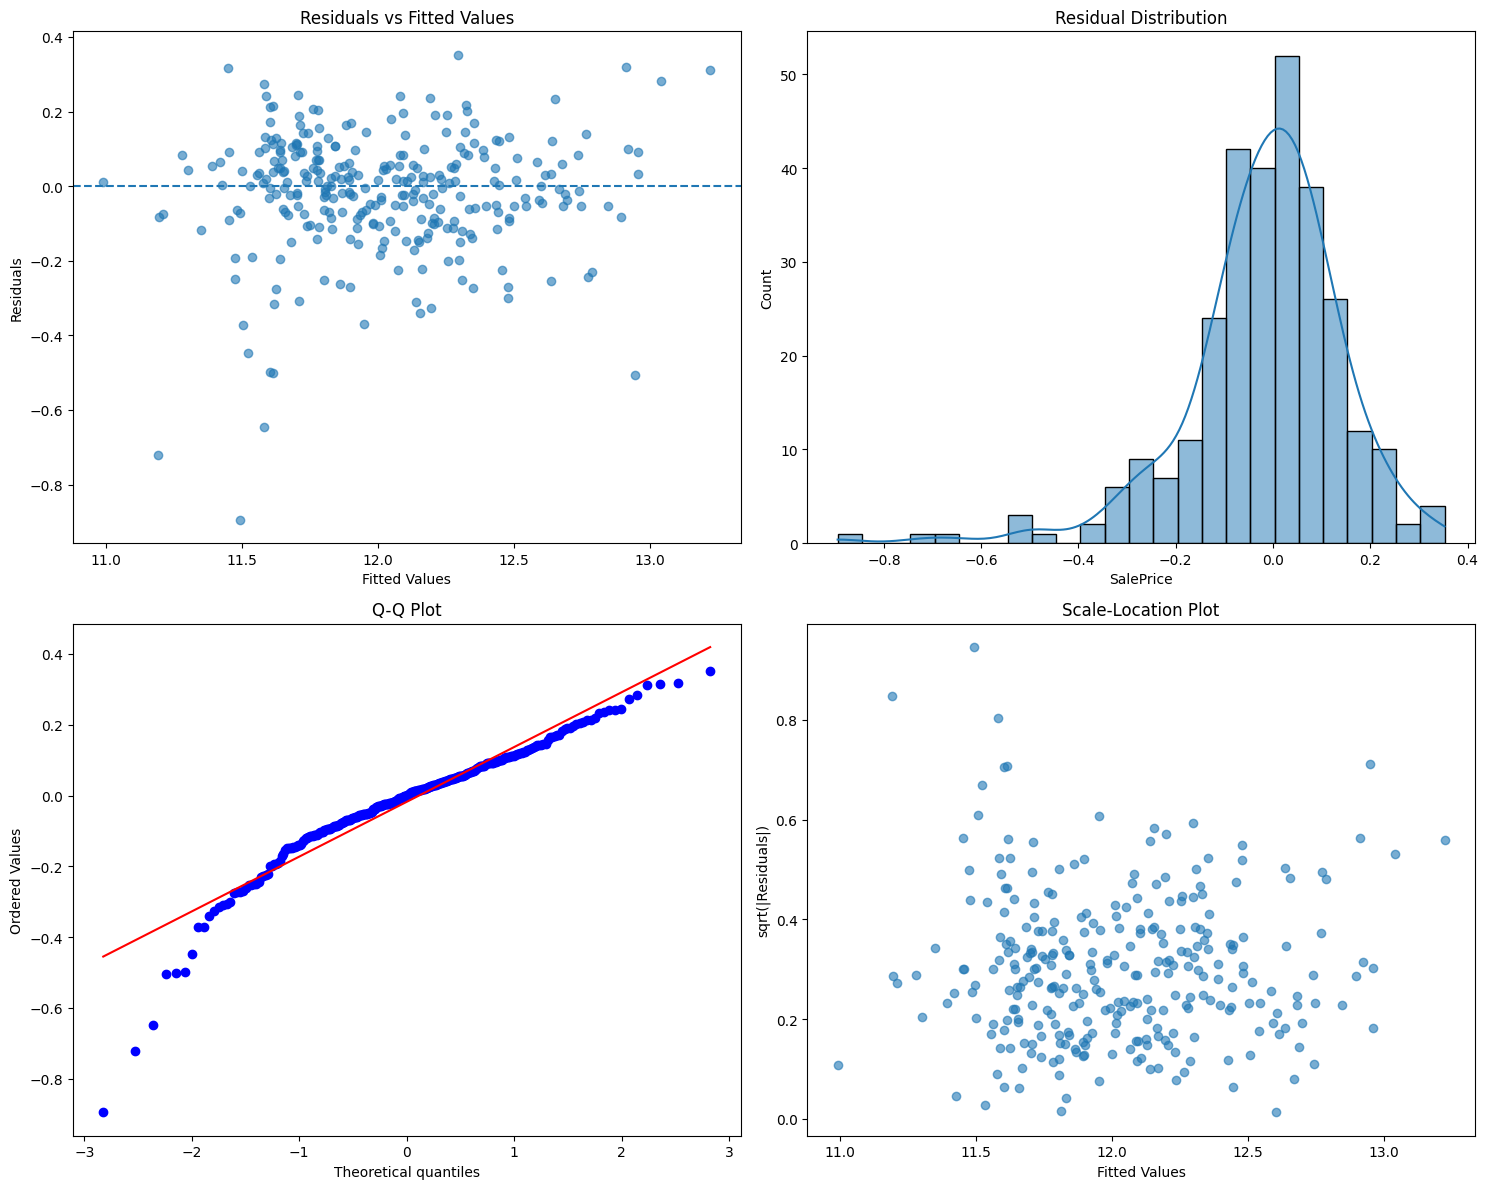


Shapiro-Wilk Test
Statistic: 0.920920872316538
P-value : 2.6081437820390078e-11
Residuals are NOT normally distributed.

Linear Regression
R² Scores: [0.85401137 0.86909736 0.61004422 0.84814256 0.86855424]
Mean R² : 0.8099699516473589
Std R²  : 0.10029482618254029
RMSE Scores: [0.16505479 0.14262905 0.23436986 0.16388725 0.133534  ]
Mean RMSE : 0.16789498796794503
Std RMSE  : 0.03538949648586046

Ridge
R² Scores: [0.85207985 0.86677157 0.64339642 0.84339677 0.86845418]
Mean R² : 0.8148197584306114
Std R²  : 0.08621665941810899
RMSE Scores: [0.16614309 0.14389054 0.22412326 0.16642842 0.13358482]
Mean RMSE : 0.16683402333811195
Std RMSE  : 0.03135159174259799

Lasso
R² Scores: [0.85411861 0.86931597 0.61327654 0.8473993  0.86939594]
Mean R² : 0.8107012707930892
Std R²  : 0.09908489598110815
RMSE Scores: [0.16499415 0.14250989 0.2333965  0.16428783 0.13310578]
Mean RMSE : 0.167658832545368
Std RMSE  : 0.03511776567846887

ElasticNet
R² Scores: [0.85302447 0.86871306 0.62216518 0.844902

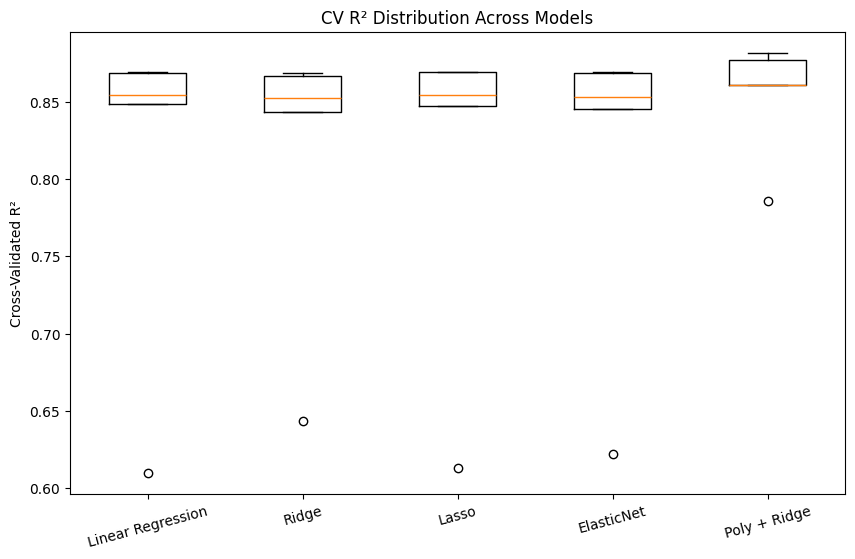

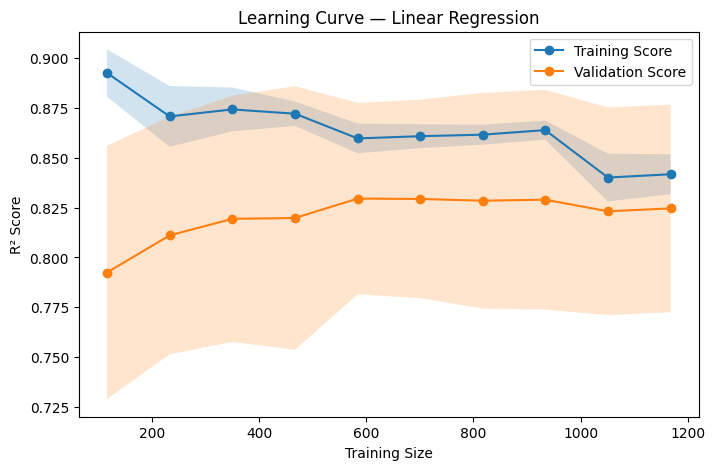

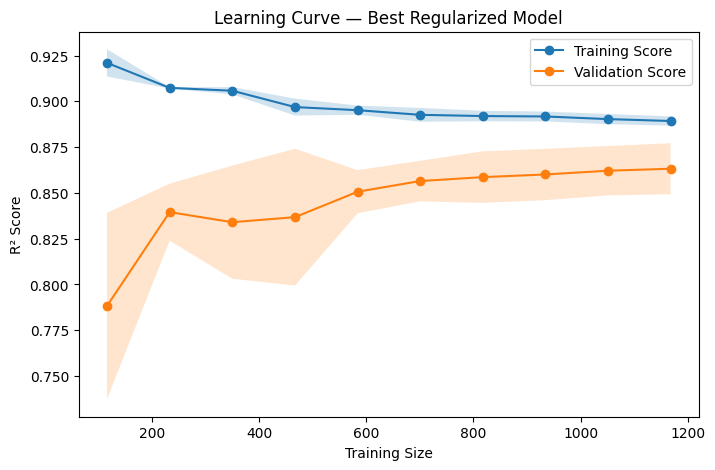

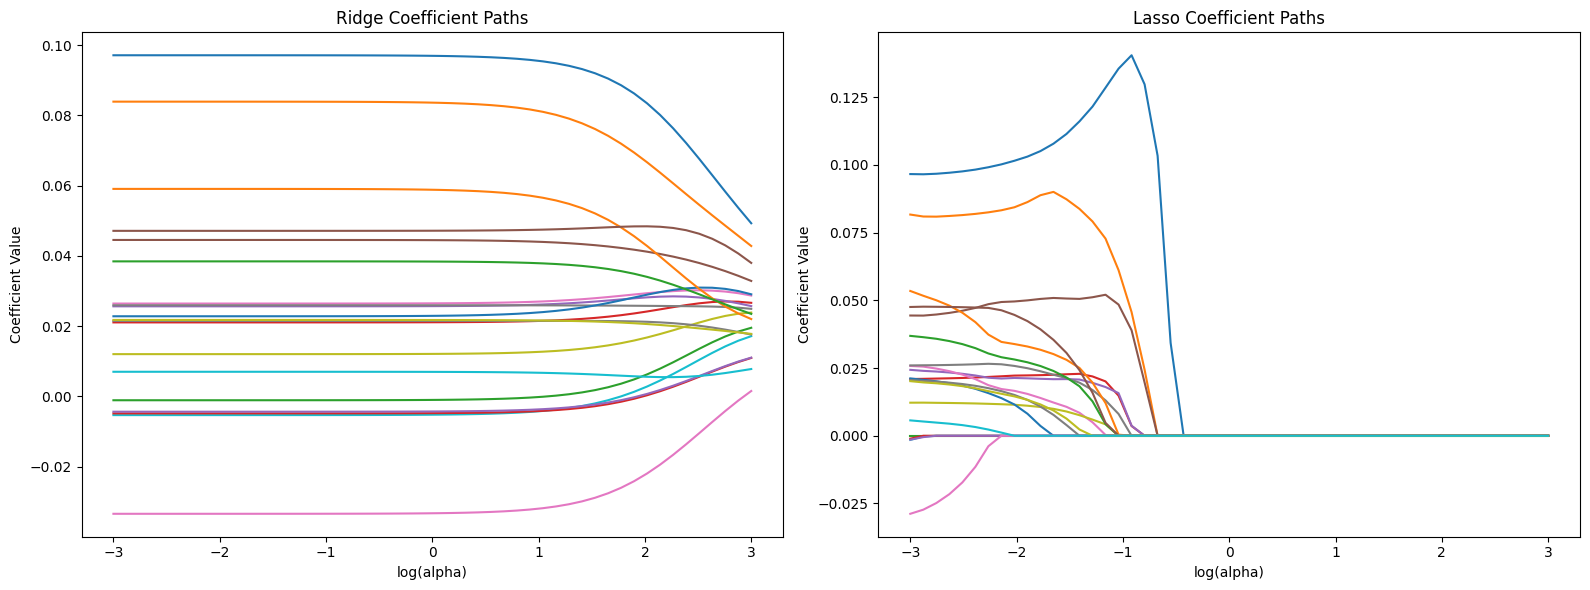


Top 3 Ridge Features Shrunk Fastest:
GarageYrBlt
Neighborhood_NridgHt
Foundation_PConc

Top 3 Lasso Features Dropped First:
             Feature  Alpha_Zero
2          ExterQual    0.001000
13  Foundation_PConc    0.001326
9           FullBath    0.001758


In [3]:
# ============================================================
# PART C — RESIDUAL ANALYSIS, CROSS-VALIDATION & DIAGNOSTICS
# (STEPS 12–15)
# ============================================================

from scipy import stats
from scipy.stats import shapiro, probplot

# ============================================================
# STEP 12 — RESIDUAL ANALYSIS & DIAGNOSTIC PLOTS
# ============================================================

# ------------------------------------------------------------
# Use Best Model
# ------------------------------------------------------------
# Assuming best_pipeline_model from Step 10 was best

best_model = best_pipeline_model

# Predictions
y_pred_best = best_model.predict(X_test)

# Residuals
residuals = y_test - y_pred_best

# ------------------------------------------------------------
# Diagnostic Figure (2x2)
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# ============================================================
# (1) Residuals vs Fitted
# ============================================================
axes[0, 0].scatter(y_pred_best, residuals, alpha=0.6)

axes[0, 0].axhline(
    y=0,
    linestyle="--"
)

axes[0, 0].set_title("Residuals vs Fitted Values")
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")

# ============================================================
# (2) Histogram + KDE
# ============================================================
sns.histplot(
    residuals,
    kde=True,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Residual Distribution")

# ============================================================
# (3) Q-Q Plot
# ============================================================
probplot(
    residuals,
    dist="norm",
    plot=axes[1, 0]
)

axes[1, 0].set_title("Q-Q Plot")

# ============================================================
# (4) Scale-Location Plot
# ============================================================
sqrt_abs_residuals = np.sqrt(np.abs(residuals))

axes[1, 1].scatter(
    y_pred_best,
    sqrt_abs_residuals,
    alpha=0.6
)

axes[1, 1].set_title("Scale-Location Plot")
axes[1, 1].set_xlabel("Fitted Values")
axes[1, 1].set_ylabel("sqrt(|Residuals|)")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Shapiro-Wilk Test
# ------------------------------------------------------------
shapiro_stat, shapiro_p = shapiro(residuals)

print("\nShapiro-Wilk Test")
print("Statistic:", shapiro_stat)
print("P-value :", shapiro_p)

if shapiro_p > 0.05:
    print("Residuals appear approximately normally distributed.")
else:
    print("Residuals are NOT normally distributed.")


# ============================================================
# STEP 13 — 5-FOLD CROSS VALIDATION
# ============================================================

from sklearn.model_selection import cross_val_score

# ------------------------------------------------------------
# Define Models
# ------------------------------------------------------------
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", best_ridge_model)
    ]),

    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", best_lasso_model)
    ]),

    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", best_elastic_model)
    ]),

    "Poly + Ridge": best_pipeline_model
}

# ------------------------------------------------------------
# KFold
# ------------------------------------------------------------
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = {}

# ------------------------------------------------------------
# Cross Validation
# ------------------------------------------------------------
for name, model in models.items():

    # R² Scores
    r2_scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="r2"
    )

    # RMSE Scores
    rmse_scores = -cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="neg_root_mean_squared_error"
    )

    cv_results[name] = r2_scores

    print(f"\n{name}")
    print("R² Scores:", r2_scores)
    print("Mean R² :", r2_scores.mean())
    print("Std R²  :", r2_scores.std())

    print("RMSE Scores:", rmse_scores)
    print("Mean RMSE :", rmse_scores.mean())
    print("Std RMSE  :", rmse_scores.std())

# ------------------------------------------------------------
# Box Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.boxplot(
    cv_results.values(),
    labels=cv_results.keys()
)

plt.ylabel("Cross-Validated R²")
plt.title("CV R² Distribution Across Models")

plt.xticks(rotation=15)

plt.show()


# ============================================================
# STEP 14 — LEARNING CURVES
# ============================================================

from sklearn.model_selection import learning_curve

# ------------------------------------------------------------
# Models for Learning Curves
# ------------------------------------------------------------
learning_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Best Regularized Model": best_pipeline_model
}

# ------------------------------------------------------------
# Plot Learning Curves
# ------------------------------------------------------------
for name, model in learning_models.items():

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring="r2",
        train_sizes=np.linspace(0.1, 1.0, 10),
        random_state=42
    )

    # Mean and Std
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)

    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    plt.figure(figsize=(8, 5))

    # Training Curve
    plt.plot(
        train_sizes,
        train_mean,
        marker="o",
        label="Training Score"
    )

    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2
    )

    # Validation Curve
    plt.plot(
        train_sizes,
        val_mean,
        marker="o",
        label="Validation Score"
    )

    plt.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.2
    )

    plt.xlabel("Training Size")
    plt.ylabel("R² Score")
    plt.title(f"Learning Curve — {name}")

    plt.legend()

    plt.show()


# ============================================================
# STEP 15 — COEFFICIENT PATHS
# ============================================================

alphas = np.logspace(-3, 3, 50)

# ------------------------------------------------------------
# RIDGE COEFFICIENT PATH
# ------------------------------------------------------------
ridge_coefficients = []

for alpha in alphas:

    ridge = Ridge(alpha=alpha)

    ridge.fit(X_train_scaled, y_train)

    ridge_coefficients.append(ridge.coef_)

ridge_coefficients = np.array(ridge_coefficients)

# ------------------------------------------------------------
# LASSO COEFFICIENT PATH
# ------------------------------------------------------------
lasso_coefficients = []

for alpha in alphas:

    lasso = Lasso(
        alpha=alpha,
        max_iter=10000
    )

    lasso.fit(X_train_scaled, y_train)

    lasso_coefficients.append(lasso.coef_)

lasso_coefficients = np.array(lasso_coefficients)

# ------------------------------------------------------------
# Plot Both Paths
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================================
# Ridge Plot
# ============================================================
for i in range(len(X.columns)):

    axes[0].plot(
        np.log10(alphas),
        ridge_coefficients[:, i]
    )

axes[0].set_title("Ridge Coefficient Paths")
axes[0].set_xlabel("log(alpha)")
axes[0].set_ylabel("Coefficient Value")

# ============================================================
# Lasso Plot
# ============================================================
for i in range(len(X.columns)):

    axes[1].plot(
        np.log10(alphas),
        lasso_coefficients[:, i]
    )

axes[1].set_title("Lasso Coefficient Paths")
axes[1].set_xlabel("log(alpha)")
axes[1].set_ylabel("Coefficient Value")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Features Shrinking Fastest (Ridge)
# ------------------------------------------------------------
ridge_shrink = np.abs(ridge_coefficients[-1])

ridge_smallest = np.argsort(ridge_shrink)[:3]

print("\nTop 3 Ridge Features Shrunk Fastest:")

for idx in ridge_smallest:
    print(X.columns[idx])

# ------------------------------------------------------------
# Features Eliminated First (Lasso)
# ------------------------------------------------------------
lasso_zero_counts = []

for i in range(len(X.columns)):

    zero_alpha = None

    for j in range(len(alphas)):

        if lasso_coefficients[j, i] == 0:
            zero_alpha = alphas[j]
            break

    lasso_zero_counts.append(zero_alpha)

lasso_drop_order = pd.DataFrame({
    "Feature": X.columns,
    "Alpha_Zero": lasso_zero_counts
})

lasso_drop_order = lasso_drop_order.sort_values(
    by="Alpha_Zero"
)

print("\nTop 3 Lasso Features Dropped First:")
print(lasso_drop_order.head(3))

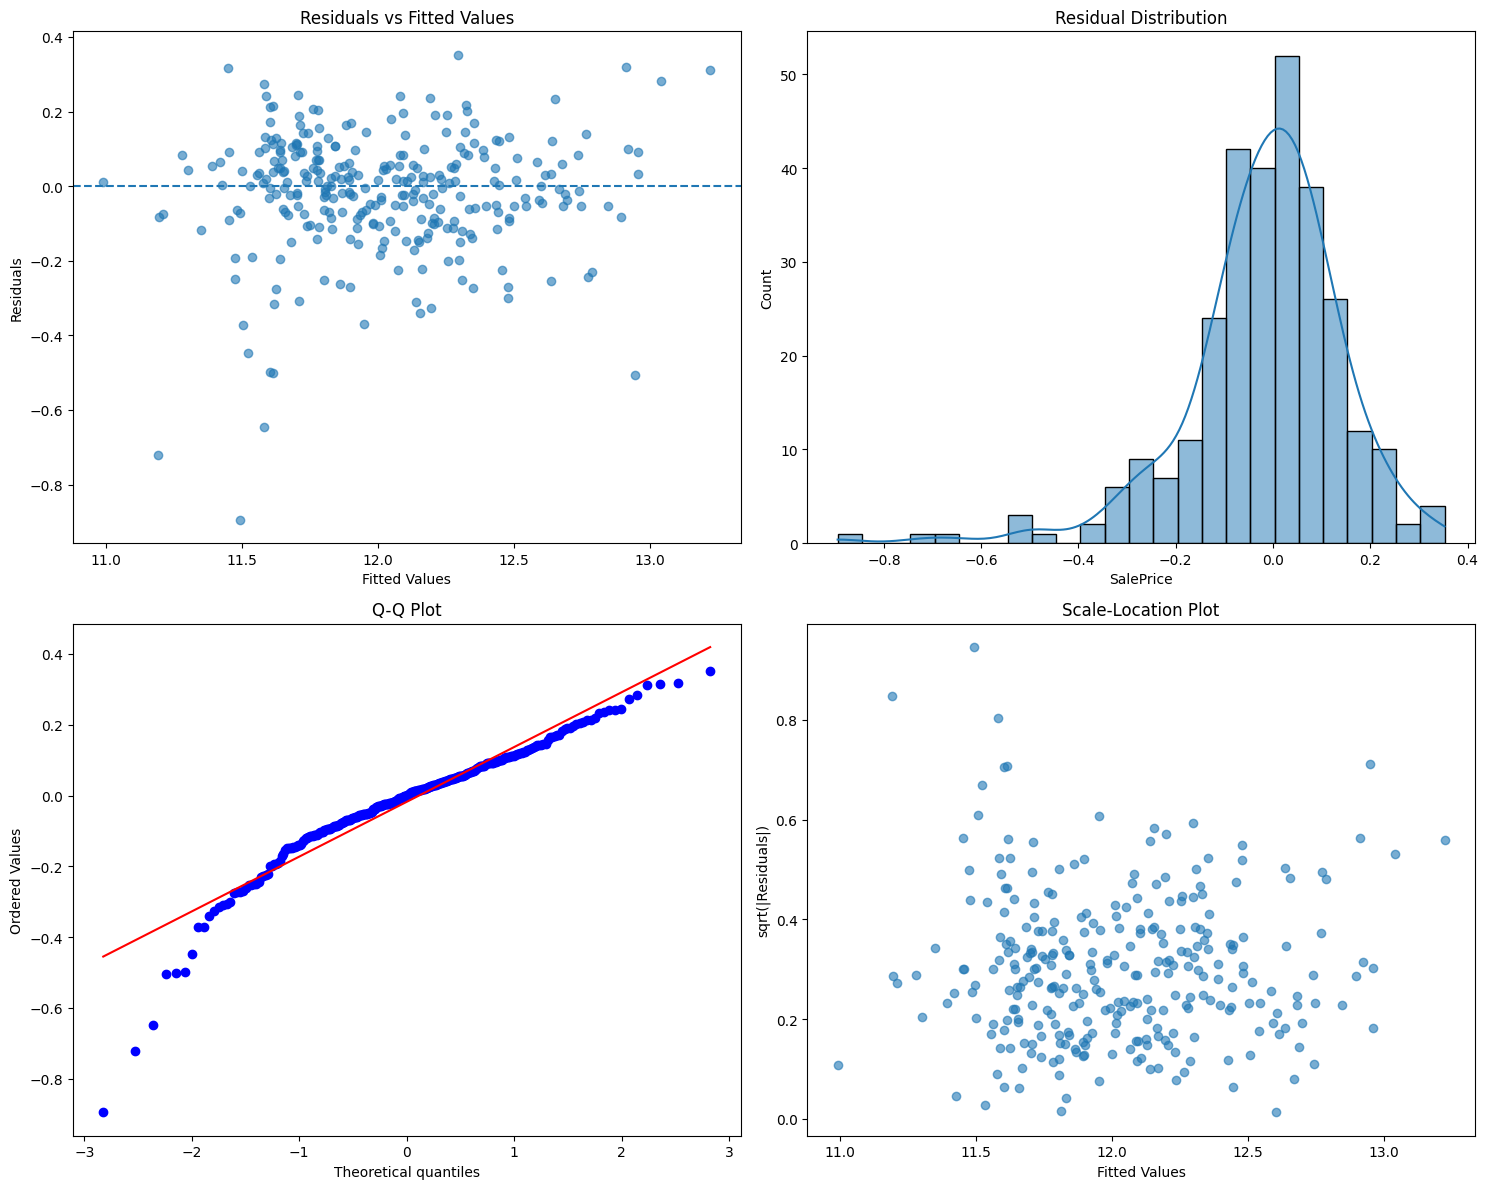


Shapiro-Wilk Test
Statistic: 0.920920872316538
P-value : 2.6081437820390078e-11
Residuals are NOT normally distributed.

Linear Regression
R² Scores: [0.85401137 0.86909736 0.61004422 0.84814256 0.86855424]
Mean R² : 0.8099699516473589
Std R²  : 0.10029482618254029
RMSE Scores: [0.16505479 0.14262905 0.23436986 0.16388725 0.133534  ]
Mean RMSE : 0.16789498796794503
Std RMSE  : 0.03538949648586046

Ridge
R² Scores: [0.85207985 0.86677157 0.64339642 0.84339677 0.86845418]
Mean R² : 0.8148197584306114
Std R²  : 0.08621665941810899
RMSE Scores: [0.16614309 0.14389054 0.22412326 0.16642842 0.13358482]
Mean RMSE : 0.16683402333811195
Std RMSE  : 0.03135159174259799

Lasso
R² Scores: [0.85411861 0.86931597 0.61327654 0.8473993  0.86939594]
Mean R² : 0.8107012707930892
Std R²  : 0.09908489598110815
RMSE Scores: [0.16499415 0.14250989 0.2333965  0.16428783 0.13310578]
Mean RMSE : 0.167658832545368
Std RMSE  : 0.03511776567846887

ElasticNet
R² Scores: [0.85302447 0.86871306 0.62216518 0.844902

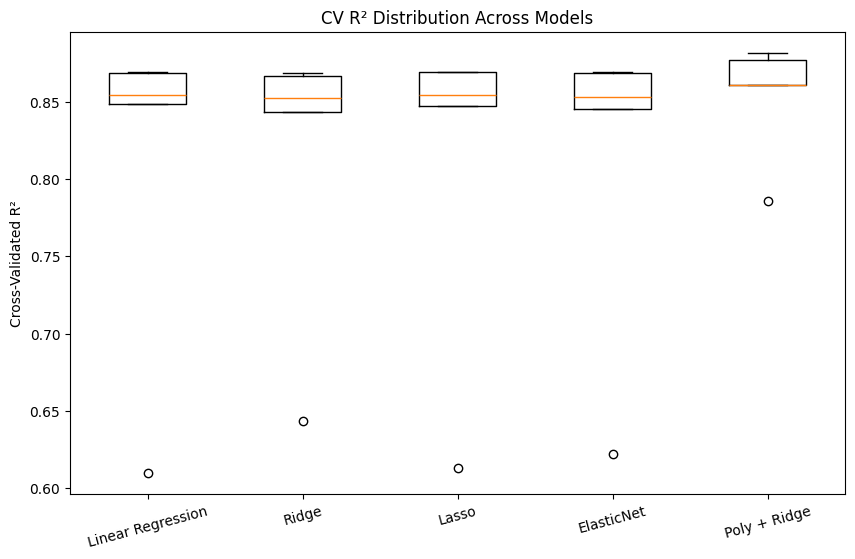

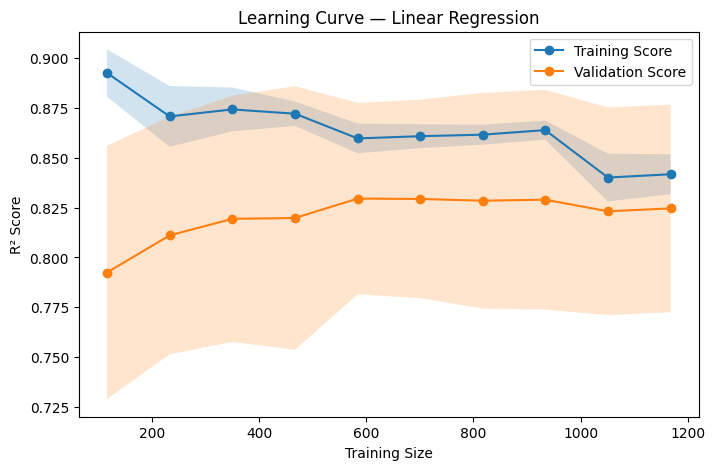

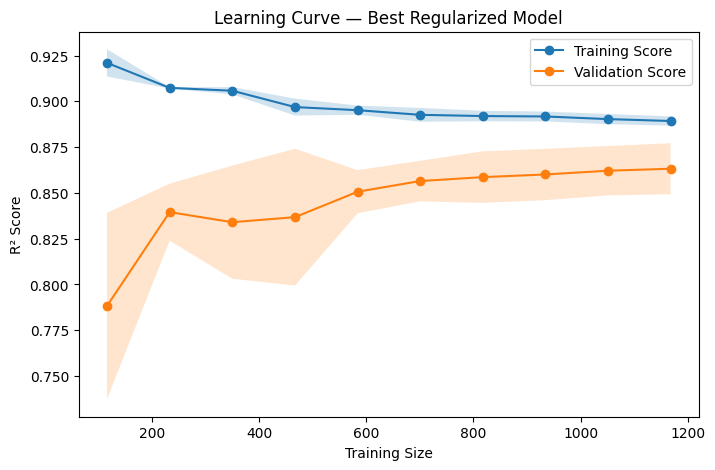

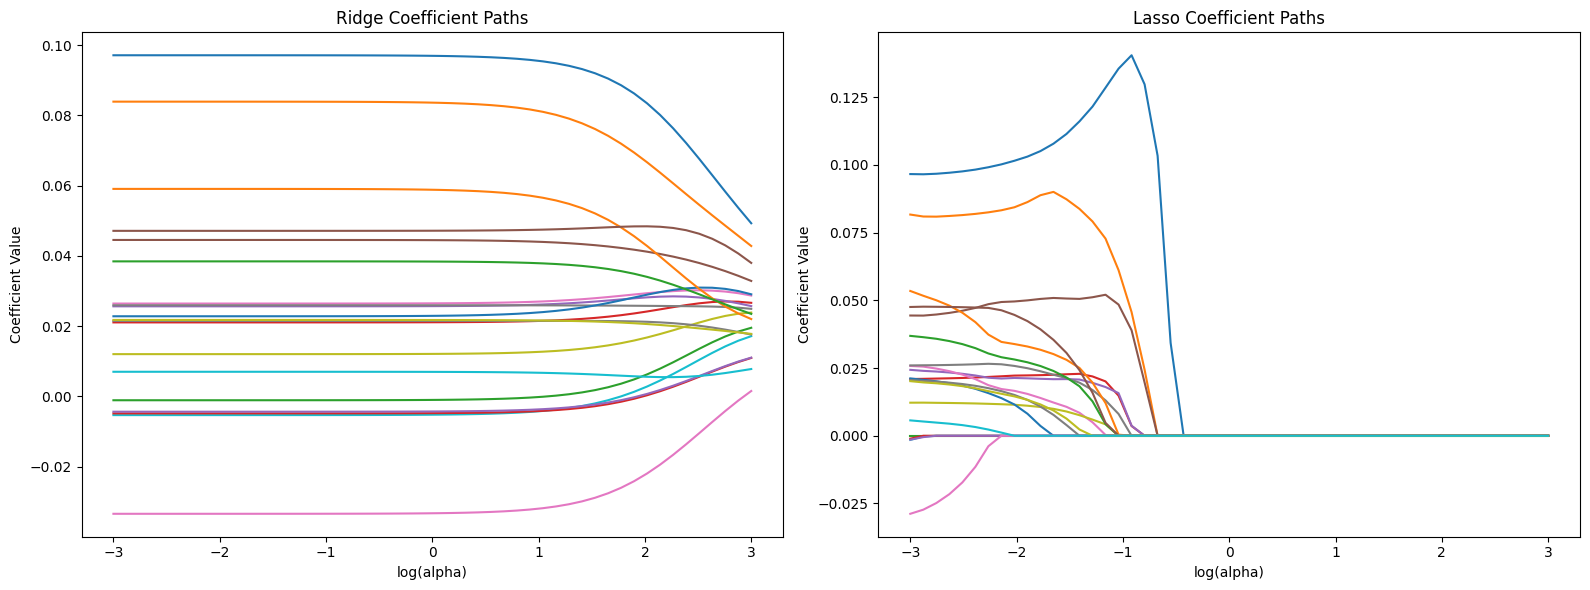


Top 3 Ridge Features Shrunk Fastest:
GarageYrBlt
Neighborhood_NridgHt
Foundation_PConc

Top 3 Lasso Features Dropped First:
             Feature  Alpha_Zero
2          ExterQual    0.001000
13  Foundation_PConc    0.001326
9           FullBath    0.001758


In [4]:
# ============================================================
# PART C — RESIDUAL ANALYSIS, CROSS-VALIDATION & DIAGNOSTICS
# (STEPS 12–15)
# ============================================================

from scipy import stats
from scipy.stats import shapiro, probplot

# ============================================================
# STEP 12 — RESIDUAL ANALYSIS & DIAGNOSTIC PLOTS
# ============================================================

# ------------------------------------------------------------
# Use Best Model
# ------------------------------------------------------------
# Assuming best_pipeline_model from Step 10 was best

best_model = best_pipeline_model

# Predictions
y_pred_best = best_model.predict(X_test)

# Residuals
residuals = y_test - y_pred_best

# ------------------------------------------------------------
# Diagnostic Figure (2x2)
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# ============================================================
# (1) Residuals vs Fitted
# ============================================================
axes[0, 0].scatter(y_pred_best, residuals, alpha=0.6)

axes[0, 0].axhline(
    y=0,
    linestyle="--"
)

axes[0, 0].set_title("Residuals vs Fitted Values")
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")

# ============================================================
# (2) Histogram + KDE
# ============================================================
sns.histplot(
    residuals,
    kde=True,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Residual Distribution")

# ============================================================
# (3) Q-Q Plot
# ============================================================
probplot(
    residuals,
    dist="norm",
    plot=axes[1, 0]
)

axes[1, 0].set_title("Q-Q Plot")

# ============================================================
# (4) Scale-Location Plot
# ============================================================
sqrt_abs_residuals = np.sqrt(np.abs(residuals))

axes[1, 1].scatter(
    y_pred_best,
    sqrt_abs_residuals,
    alpha=0.6
)

axes[1, 1].set_title("Scale-Location Plot")
axes[1, 1].set_xlabel("Fitted Values")
axes[1, 1].set_ylabel("sqrt(|Residuals|)")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Shapiro-Wilk Test
# ------------------------------------------------------------
shapiro_stat, shapiro_p = shapiro(residuals)

print("\nShapiro-Wilk Test")
print("Statistic:", shapiro_stat)
print("P-value :", shapiro_p)

if shapiro_p > 0.05:
    print("Residuals appear approximately normally distributed.")
else:
    print("Residuals are NOT normally distributed.")


# ============================================================
# STEP 13 — 5-FOLD CROSS VALIDATION
# ============================================================

from sklearn.model_selection import cross_val_score

# ------------------------------------------------------------
# Define Models
# ------------------------------------------------------------
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", best_ridge_model)
    ]),

    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", best_lasso_model)
    ]),

    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", best_elastic_model)
    ]),

    "Poly + Ridge": best_pipeline_model
}

# ------------------------------------------------------------
# KFold
# ------------------------------------------------------------
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = {}

# ------------------------------------------------------------
# Cross Validation
# ------------------------------------------------------------
for name, model in models.items():

    # R² Scores
    r2_scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="r2"
    )

    # RMSE Scores
    rmse_scores = -cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="neg_root_mean_squared_error"
    )

    cv_results[name] = r2_scores

    print(f"\n{name}")
    print("R² Scores:", r2_scores)
    print("Mean R² :", r2_scores.mean())
    print("Std R²  :", r2_scores.std())

    print("RMSE Scores:", rmse_scores)
    print("Mean RMSE :", rmse_scores.mean())
    print("Std RMSE  :", rmse_scores.std())

# ------------------------------------------------------------
# Box Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.boxplot(
    cv_results.values(),
    labels=cv_results.keys()
)

plt.ylabel("Cross-Validated R²")
plt.title("CV R² Distribution Across Models")

plt.xticks(rotation=15)

plt.show()


# ============================================================
# STEP 14 — LEARNING CURVES
# ============================================================

from sklearn.model_selection import learning_curve

# ------------------------------------------------------------
# Models for Learning Curves
# ------------------------------------------------------------
learning_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Best Regularized Model": best_pipeline_model
}

# ------------------------------------------------------------
# Plot Learning Curves
# ------------------------------------------------------------
for name, model in learning_models.items():

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring="r2",
        train_sizes=np.linspace(0.1, 1.0, 10),
        random_state=42
    )

    # Mean and Std
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)

    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    plt.figure(figsize=(8, 5))

    # Training Curve
    plt.plot(
        train_sizes,
        train_mean,
        marker="o",
        label="Training Score"
    )

    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2
    )

    # Validation Curve
    plt.plot(
        train_sizes,
        val_mean,
        marker="o",
        label="Validation Score"
    )

    plt.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.2
    )

    plt.xlabel("Training Size")
    plt.ylabel("R² Score")
    plt.title(f"Learning Curve — {name}")

    plt.legend()

    plt.show()


# ============================================================
# STEP 15 — COEFFICIENT PATHS
# ============================================================

alphas = np.logspace(-3, 3, 50)

# ------------------------------------------------------------
# RIDGE COEFFICIENT PATH
# ------------------------------------------------------------
ridge_coefficients = []

for alpha in alphas:

    ridge = Ridge(alpha=alpha)

    ridge.fit(X_train_scaled, y_train)

    ridge_coefficients.append(ridge.coef_)

ridge_coefficients = np.array(ridge_coefficients)

# ------------------------------------------------------------
# LASSO COEFFICIENT PATH
# ------------------------------------------------------------
lasso_coefficients = []

for alpha in alphas:

    lasso = Lasso(
        alpha=alpha,
        max_iter=10000
    )

    lasso.fit(X_train_scaled, y_train)

    lasso_coefficients.append(lasso.coef_)

lasso_coefficients = np.array(lasso_coefficients)

# ------------------------------------------------------------
# Plot Both Paths
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================================
# Ridge Plot
# ============================================================
for i in range(len(X.columns)):

    axes[0].plot(
        np.log10(alphas),
        ridge_coefficients[:, i]
    )

axes[0].set_title("Ridge Coefficient Paths")
axes[0].set_xlabel("log(alpha)")
axes[0].set_ylabel("Coefficient Value")

# ============================================================
# Lasso Plot
# ============================================================
for i in range(len(X.columns)):

    axes[1].plot(
        np.log10(alphas),
        lasso_coefficients[:, i]
    )

axes[1].set_title("Lasso Coefficient Paths")
axes[1].set_xlabel("log(alpha)")
axes[1].set_ylabel("Coefficient Value")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Features Shrinking Fastest (Ridge)
# ------------------------------------------------------------
ridge_shrink = np.abs(ridge_coefficients[-1])

ridge_smallest = np.argsort(ridge_shrink)[:3]

print("\nTop 3 Ridge Features Shrunk Fastest:")

for idx in ridge_smallest:
    print(X.columns[idx])

# ------------------------------------------------------------
# Features Eliminated First (Lasso)
# ------------------------------------------------------------
lasso_zero_counts = []

for i in range(len(X.columns)):

    zero_alpha = None

    for j in range(len(alphas)):

        if lasso_coefficients[j, i] == 0:
            zero_alpha = alphas[j]
            break

    lasso_zero_counts.append(zero_alpha)

lasso_drop_order = pd.DataFrame({
    "Feature": X.columns,
    "Alpha_Zero": lasso_zero_counts
})

lasso_drop_order = lasso_drop_order.sort_values(
    by="Alpha_Zero"
)

print("\nTop 3 Lasso Features Dropped First:")
print(lasso_drop_order.head(3))

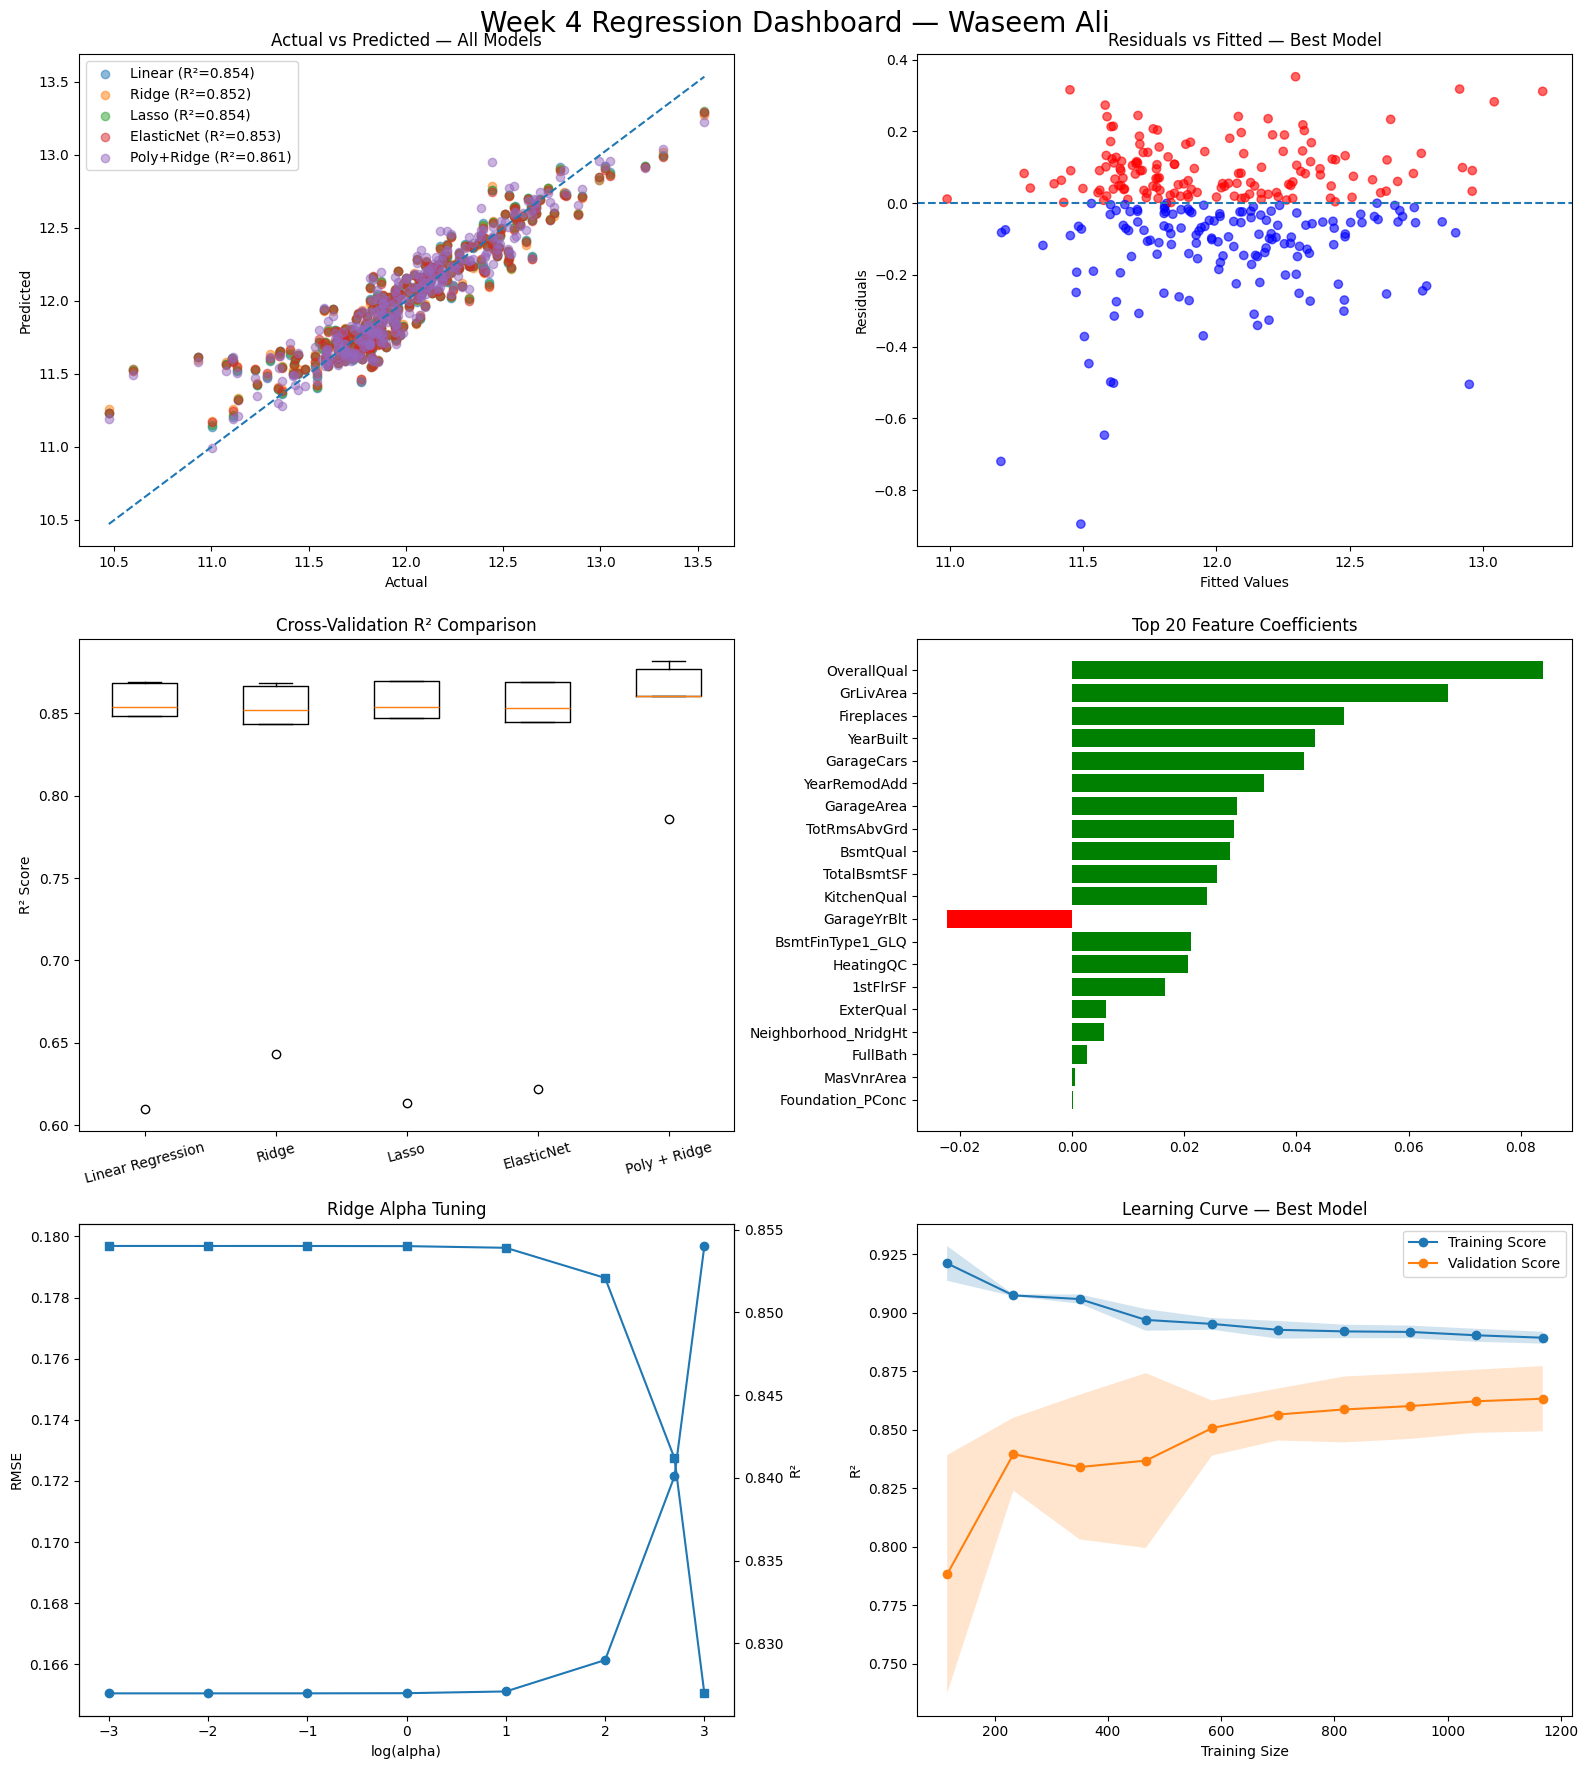

Dashboard Saved Successfully!

Top 10 Largest Prediction Errors
      index  actual_price  predicted_price          error   pct_error
30       30       40000.0     97893.983207  -57893.983207  144.734958
916     916       35311.0     72560.024973  -37249.024973  105.488445
812     812       55993.0    106940.795567  -50947.795567   90.989580
581     581      253293.0    419807.833279 -166514.833279   65.740006
398     398       67000.0    110677.977033  -43677.977033   65.191010
874     874       66500.0    109481.501524  -42981.501524   64.633837
1432   1432       64500.0    100897.566597  -36397.566597   56.430336
1279   1279       68400.0     99216.166692  -30816.166692   45.052875
772     772      107000.0    154903.792703  -47903.792703   44.769900
628     628      135000.0    189839.956459  -54839.956459   40.622190

Model Saved Successfully!

Loaded Model Prediction:
[135767.54465361]


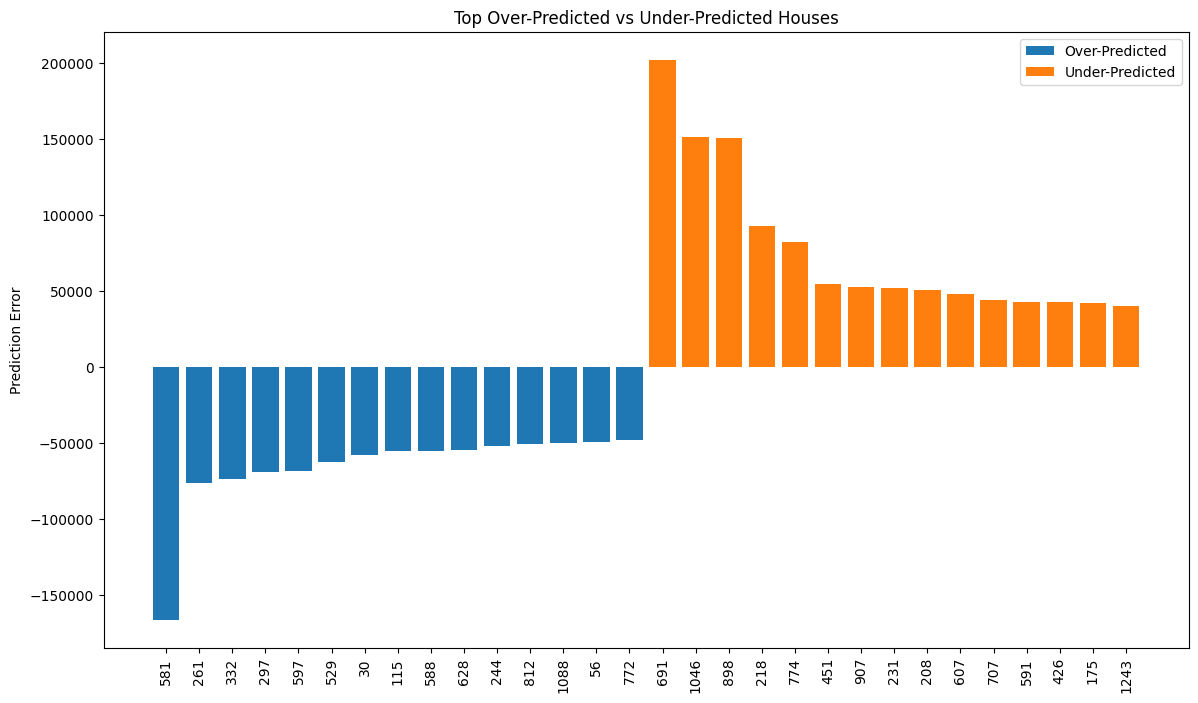

In [5]:
# ============================================================
# PART D — FINAL DASHBOARD, PREDICTIONS & REPORT
# (STEPS 16–18)
# ============================================================

import joblib

# ============================================================
# STEP 16 — COMPLETE 6-CHART MODEL EVALUATION DASHBOARD
# ============================================================

# ------------------------------------------------------------
# Predictions for All Models
# ------------------------------------------------------------

linear_pred = y_test_pred
ridge_pred = best_ridge_model.predict(X_test_scaled)
lasso_pred = best_lasso_model.predict(X_test_scaled)
elastic_pred = best_elastic_model.predict(X_test_scaled)
pipeline_pred = best_pipeline_model.predict(X_test)

# ------------------------------------------------------------
# Create Dashboard
# ------------------------------------------------------------

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

fig.suptitle(
    "Week 4 Regression Dashboard — Waseem Ali",
    fontsize=20
)

# ============================================================
# CHART 1 — ACTUAL VS PREDICTED (ALL MODELS)
# ============================================================

model_predictions = {
    "Linear": linear_pred,
    "Ridge": ridge_pred,
    "Lasso": lasso_pred,
    "ElasticNet": elastic_pred,
    "Poly+Ridge": pipeline_pred
}

for name, pred in model_predictions.items():

    r2 = r2_score(y_test, pred)

    axes[0, 0].scatter(
        y_test,
        pred,
        alpha=0.5,
        label=f"{name} (R²={r2:.3f})"
    )

# Perfect Line
axes[0, 0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

axes[0, 0].set_title("Actual vs Predicted — All Models")
axes[0, 0].set_xlabel("Actual")
axes[0, 0].set_ylabel("Predicted")
axes[0, 0].legend()

# ============================================================
# CHART 2 — RESIDUALS VS FITTED
# ============================================================

best_residuals = y_test - pipeline_pred

colors = [
    "red" if r > 0 else "blue"
    for r in best_residuals
]

axes[0, 1].scatter(
    pipeline_pred,
    best_residuals,
    c=colors,
    alpha=0.6
)

axes[0, 1].axhline(
    y=0,
    linestyle="--"
)

axes[0, 1].set_title("Residuals vs Fitted — Best Model")
axes[0, 1].set_xlabel("Fitted Values")
axes[0, 1].set_ylabel("Residuals")

# ============================================================
# CHART 3 — CV R² BOX PLOTS
# ============================================================

axes[1, 0].boxplot(
    cv_results.values(),
    labels=cv_results.keys()
)

axes[1, 0].set_title("Cross-Validation R² Comparison")
axes[1, 0].set_ylabel("R² Score")

for label in axes[1, 0].get_xticklabels():
    label.set_rotation(15)

# ============================================================
# CHART 4 — FEATURE COEFFICIENTS
# ============================================================

# Best Regularized Model = Ridge
ridge_coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_ridge_model.coef_
})

ridge_coeff_df["Abs"] = ridge_coeff_df["Coefficient"].abs()

top20 = ridge_coeff_df.sort_values(
    by="Abs",
    ascending=False
).head(20)

colors = [
    "green" if c > 0 else "red"
    for c in top20["Coefficient"]
]

axes[1, 1].barh(
    top20["Feature"],
    top20["Coefficient"],
    color=colors
)

axes[1, 1].invert_yaxis()

axes[1, 1].set_title("Top 20 Feature Coefficients")

# ============================================================
# CHART 5 — RIDGE ALPHA TUNING
# ============================================================

ax1 = axes[2, 0]

ax1.plot(
    np.log10(ridge_results_df["alpha"]),
    ridge_results_df["RMSE"],
    marker="o",
    label="RMSE"
)

ax1.set_xlabel("log(alpha)")
ax1.set_ylabel("RMSE")

ax2 = ax1.twinx()

ax2.plot(
    np.log10(ridge_results_df["alpha"]),
    ridge_results_df["R2"],
    marker="s",
    label="R²"
)

ax2.set_ylabel("R²")

ax1.set_title("Ridge Alpha Tuning")

# ============================================================
# CHART 6 — LEARNING CURVE (BEST MODEL)
# ============================================================

train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline_model,
    X,
    y,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

axes[2, 1].plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Score"
)

axes[2, 1].fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

axes[2, 1].plot(
    train_sizes,
    val_mean,
    marker="o",
    label="Validation Score"
)

axes[2, 1].fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

axes[2, 1].set_title("Learning Curve — Best Model")
axes[2, 1].set_xlabel("Training Size")
axes[2, 1].set_ylabel("R²")
axes[2, 1].legend()

# ------------------------------------------------------------
# Save Dashboard
# ------------------------------------------------------------

plt.tight_layout()

plt.savefig(
    "week4_dashboard.png",
    dpi=150
)

plt.show()

print("Dashboard Saved Successfully!")


# ============================================================
# STEP 17 — GENERATE PREDICTIONS & SAVE MODEL
# ============================================================

# ------------------------------------------------------------
# Predictions in Dollar Scale
# ------------------------------------------------------------

actual_prices = np.expm1(y_test)

predicted_prices = np.expm1(pipeline_pred)

# ------------------------------------------------------------
# Prediction DataFrame
# ------------------------------------------------------------

prediction_df = pd.DataFrame({
    "index": y_test.index,
    "actual_price": actual_prices,
    "predicted_price": predicted_prices
})

prediction_df["error"] = (
    prediction_df["actual_price"]
    - prediction_df["predicted_price"]
)

prediction_df["pct_error"] = (
    np.abs(prediction_df["error"])
    / prediction_df["actual_price"]
) * 100

# ------------------------------------------------------------
# Largest Prediction Errors
# ------------------------------------------------------------

largest_errors = prediction_df.reindex(
    prediction_df["pct_error"].abs().sort_values(
        ascending=False
    ).index
).head(10)

print("\nTop 10 Largest Prediction Errors")
print(largest_errors)

# ------------------------------------------------------------
# Save Model
# ------------------------------------------------------------

joblib.dump(
    best_pipeline_model,
    "week4_best_model.pkl"
)

print("\nModel Saved Successfully!")

# ------------------------------------------------------------
# Reload Model
# ------------------------------------------------------------

loaded_model = joblib.load(
    "week4_best_model.pkl"
)

# ------------------------------------------------------------
# Verify Prediction
# ------------------------------------------------------------

sample_prediction = loaded_model.predict(
    X_test.iloc[:1]
)

print("\nLoaded Model Prediction:")
print(np.expm1(sample_prediction))

# ============================================================
# OVER-PREDICTED & UNDER-PREDICTED HOUSES
# ============================================================

# ------------------------------------------------------------
# Over-Predicted
# ------------------------------------------------------------

over_predicted = prediction_df.sort_values(
    by="error"
).head(15)

# ------------------------------------------------------------
# Under-Predicted
# ------------------------------------------------------------

under_predicted = prediction_df.sort_values(
    by="error",
    ascending=False
).head(15)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(14, 8))

plt.bar(
    over_predicted["index"].astype(str),
    over_predicted["error"],
    label="Over-Predicted"
)

plt.bar(
    under_predicted["index"].astype(str),
    under_predicted["error"],
    label="Under-Predicted"
)

plt.xticks(rotation=90)

plt.ylabel("Prediction Error")
plt.title("Top Over-Predicted vs Under-Predicted Houses")

plt.legend()

plt.show()

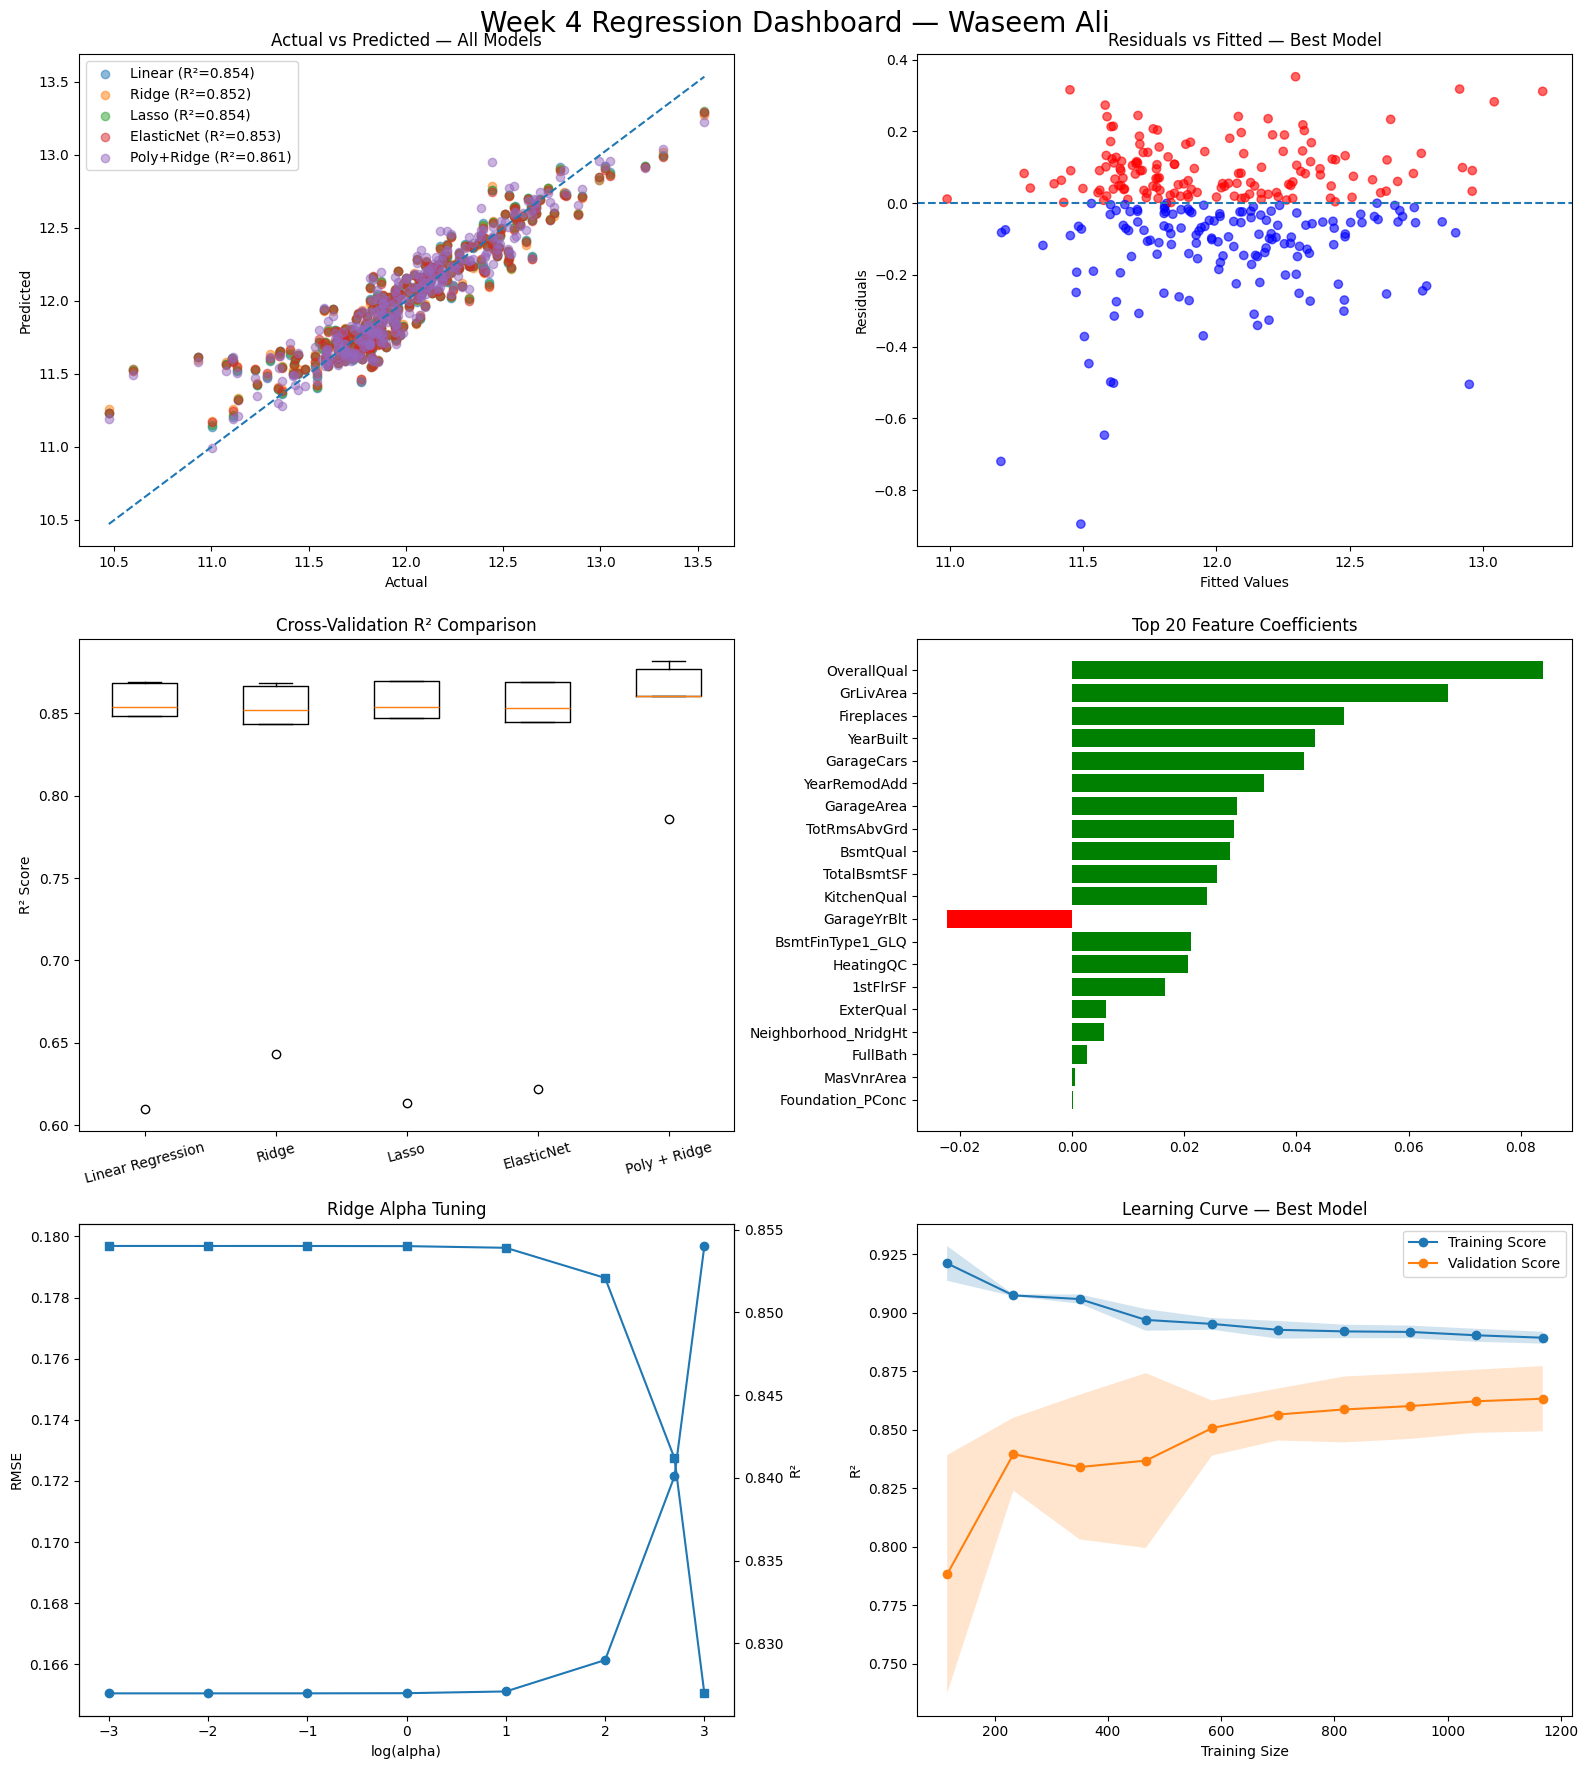

Dashboard Saved Successfully!

Top 10 Largest Prediction Errors
      index  actual_price  predicted_price          error   pct_error
30       30       40000.0     97893.983207  -57893.983207  144.734958
916     916       35311.0     72560.024973  -37249.024973  105.488445
812     812       55993.0    106940.795567  -50947.795567   90.989580
581     581      253293.0    419807.833279 -166514.833279   65.740006
398     398       67000.0    110677.977033  -43677.977033   65.191010
874     874       66500.0    109481.501524  -42981.501524   64.633837
1432   1432       64500.0    100897.566597  -36397.566597   56.430336
1279   1279       68400.0     99216.166692  -30816.166692   45.052875
772     772      107000.0    154903.792703  -47903.792703   44.769900
628     628      135000.0    189839.956459  -54839.956459   40.622190

Model Saved Successfully!

Loaded Model Prediction:
[135767.54465361]


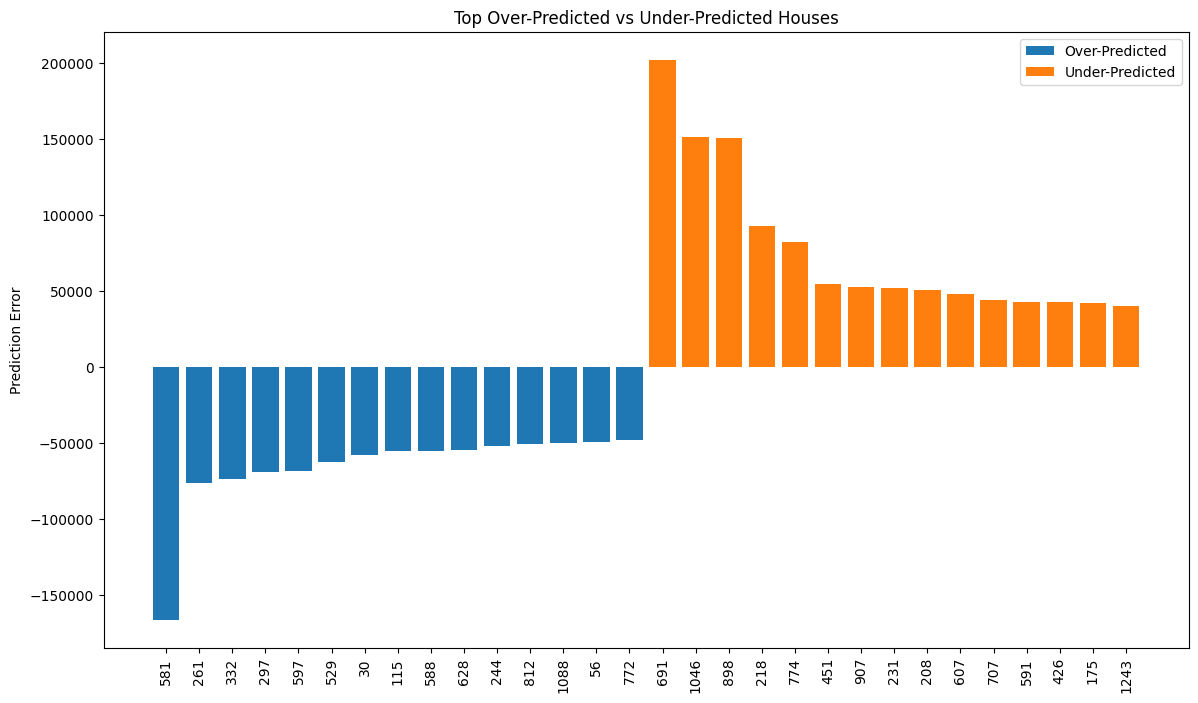